# Quantifying Nuclear Translocation of FKHR-EGFP in Response to PI3K Inhibitors: A Classical Image Segmentation Pipeline

Dataset: BBBC013 (Broad Bioimage Benchmark Collection)
Author: Freya Montgomerie

## Introduction

Nuclear translocation of the Forkhead transcription factor FKHR (FoxO1) is regulated by
PI3 kinase / PKB signalling. In proliferating cells FKHR is mostly found in the
cytoplasm. When PI3 kinase signalling is blocked FKHR is no longer exported from the
nucleus. This project uses the BBBC013 image set (Ravkin,
available from the Broad Bioimage Benchmark Collection) to quantify this translocation
in human U2OS cells expressing an FKHR-EGFP fusion protein treated with two PI3K
inhibitors, Wortmannin and LY294002, across a 9 point dose curve.

The aim of this analysis was to build a full image processing pipeline, from raw
microscopy images through to dose response curves and assay quality metrics, using
classical segmentation methods (Otsu thresholding and watershed) rather than a
pre trained deep learning model. This was done to demonstrate an understanding of the
underlying image processing steps, rather than relying on a black box tool.

## 1. Data retrieval and plate metadata

The images and plate metadata were downloaded directly from the Broad Bioimage
Benchmark Collection. The dataset consists of a 96 well plate, with 4 replicates each
of a 9 point 2-fold dilution series for two drugs (Wortmannin, rows A-D; LY294002, rows
E-H). Each well has two channels: Channel 1 is the FKHR-EGFP signal, Channel 2 is the
DNA stain (DRAQ).

In [1]:
import requests
import zipfile
from pathlib import Path
import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, remove_small_holes, dilation, disk
from skimage.measure import label, regionprops_table
from scipy import ndimage as ndi
from scipy.optimize import curve_fit
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

data_dir = Path("data/raw")
data_dir.mkdir(parents=True, exist_ok=True)
Path("results/figures").mkdir(parents=True, exist_ok=True)

img_zip_path = data_dir / "BBBC013_v1_images_bmp.zip"
if not img_zip_path.exists():
    r = requests.get("https://data.broadinstitute.org/bbbc/BBBC013/BBBC013_v1_images_bmp.zip")
    img_zip_path.write_bytes(r.content)

extract_dir = data_dir / "BBBC013_v1_images_bmp"
if not extract_dir.exists():
    with zipfile.ZipFile(img_zip_path, 'r') as z:
        z.extractall(extract_dir)

platemap_path = data_dir / "BBBC013_v1_platemap_all.txt"
if not platemap_path.exists():
    r = requests.get("https://data.broadinstitute.org/bbbc/BBBC013/BBBC013_v1_platemap_all.txt")
    platemap_path.write_bytes(r.content)

nested_path = data_dir / "BBBC013_v1_images_bmp" / "BBBC013_v1_images_bmp"
image_files = sorted(os.listdir(nested_path))
print(f"Total image files: {len(image_files)}")

with open(platemap_path) as f:
    lines = f.readlines()
doses = [float(line.strip()) for line in lines[1:97]]
print(f"Total dose values: {len(doses)}")

Total image files: 192
Total dose values: 96


## 2. Building the sample table

The platemap file lists 96 dose values in row-major well order, with no well ID attached directly. Rather than assume this ordering was
correct, I checked it against the plate layout described on the BBBC013 page: columns
1-2 should be negative controls (dose = 0), columns 3-11 the 9-point dilution series,
and column 12 the fixed positive control. Row A matched this exactly, confirming the
row major ordering assumption.

In [2]:
rows = list(string.ascii_uppercase[:8])
cols = [f"{c:02d}" for c in range(1, 13)]
well_order = [f"{r}-{c}" for r in rows for c in cols]

well_to_dose = dict(zip(well_order, doses))

def get_drug(row):
    return "Wortmannin" if row in "ABCD" else "LY294002"

def get_replicate(row):
    rep_map = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 1, "F": 2, "G": 3, "H": 4}
    return rep_map[row]

records = []
for well in well_order:
    row, col = well.split("-")
    records.append({
        "well": well, "row": row, "col": col,
        "drug": get_drug(row), "replicate": get_replicate(row),
        "dose_nM": well_to_dose[well],
        "channel1_gfp_path": nested_path / f"Channel1-{well_order.index(well)+1:02d}-{well}.BMP",
        "channel2_dna_path": nested_path / f"Channel2-{well_order.index(well)+1:02d}-{well}.BMP",
    })

sample_table = pd.DataFrame(records)
sample_table["ch1_exists"] = sample_table["channel1_gfp_path"].apply(lambda p: p.exists())
sample_table["ch2_exists"] = sample_table["channel2_dna_path"].apply(lambda p: p.exists())
print(sample_table["ch1_exists"].value_counts())
print(sample_table["ch2_exists"].value_counts())
sample_table.head()

ch1_exists
True    96
Name: count, dtype: int64
ch2_exists
True    96
Name: count, dtype: int64


,well,row,col,drug,replicate,dose_nM,channel1_gfp_path,channel2_dna_path,ch1_exists,ch2_exists
0,A-01,A,01,Wortmannin,1,0.00,data\raw\BBBC013_v1_images_bmp\BBBC013_v1_imag...,data\raw\BBBC013_v1_images_bmp\BBBC013_v1_imag...,True,True
1,A-02,A,02,Wortmannin,1,0.00,data\raw\BBBC013_v1_images_bmp\BBBC013_v1_imag...,data\raw\BBBC013_v1_images_bmp\BBBC013_v1_imag...,True,True
2,A-03,A,03,Wortmannin,1,0.98,data\raw\BBBC013_v1_images_bmp\BBBC013_v1_imag...,data\raw\BBBC013_v1_images_bmp\BBBC013_v1_imag...,True,True
3,A-04,A,04,Wortmannin,1,1.95,data\raw\BBBC013_v1_images_bmp\BBBC013_v1_imag...,data\raw\BBBC013_v1_images_bmp\BBBC013_v1_imag...,True,True
4,A-05,A,05,Wortmannin,1,3.91,data\raw\BBBC013_v1_images_bmp\BBBC013_v1_imag...,data\raw\BBBC013_v1_images_bmp\BBBC013_v1_imag...,True,True


## 3. Example images

Before running any segmentation, I looked at a negative control well and the
Wortmannin positive control well (150nM) side by side. This confirms the assay
behaves as expected before any quantification is attempted: in the negative control,
GFP signal is spread through the whole cell; in the positive control, it is
concentrated into bright spots that match the shape and position of the nuclei in
the DNA channel.

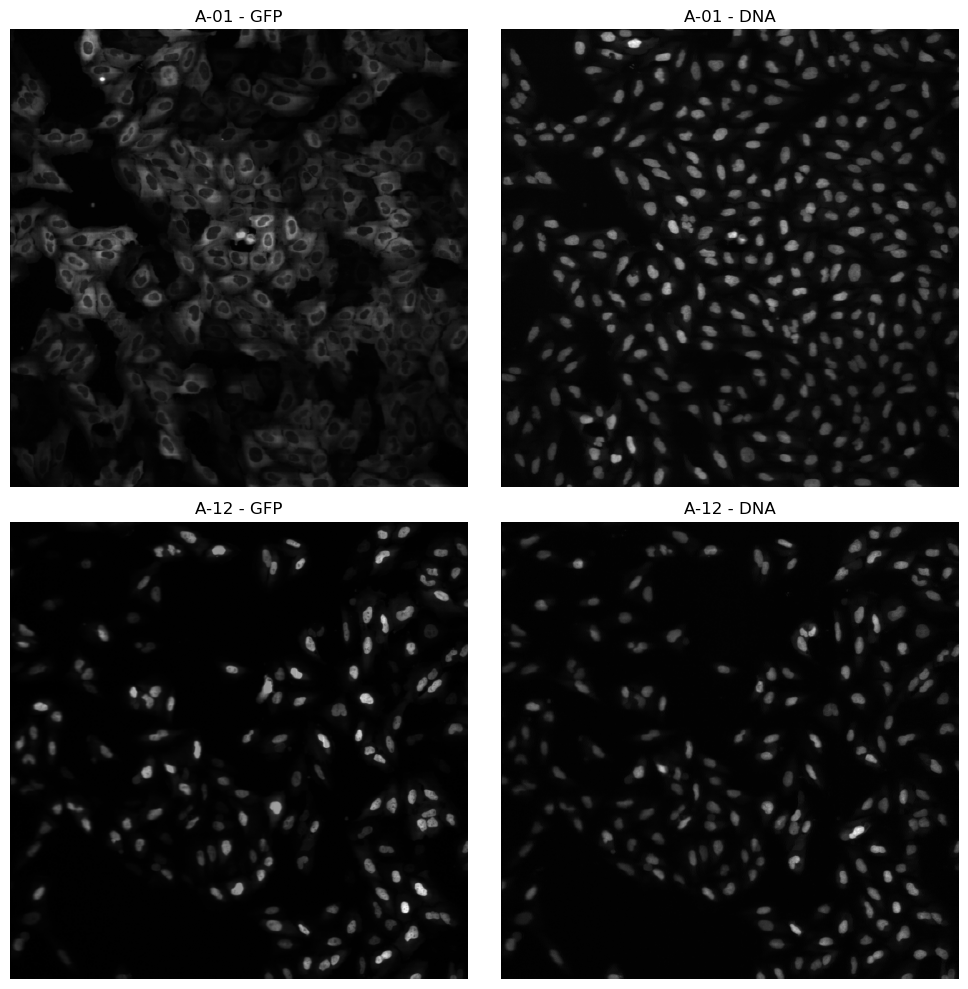

In [3]:
neg_well = sample_table[(sample_table["dose_nM"] == 0) & (sample_table["drug"] == "Wortmannin") & (sample_table["replicate"] == 1)].iloc[0]
pos_well = sample_table[(sample_table["dose_nM"] == 150) & (sample_table["drug"] == "Wortmannin") & (sample_table["replicate"] == 1)].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i, well_row in enumerate([neg_well, pos_well]):
    gfp = io.imread(well_row["channel1_gfp_path"])
    dna = io.imread(well_row["channel2_dna_path"])
    axes[i, 0].imshow(gfp, cmap="gray")
    axes[i, 0].set_title(f"{well_row['well']} - GFP")
    axes[i, 1].imshow(dna, cmap="gray")
    axes[i, 1].set_title(f"{well_row['well']} - DNA")
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.savefig("results/figures/example_images_neg_vs_pos.png", dpi=150)
plt.show()

## 4. Segmentation pipeline

Nuclei were segmented from the DNA channel using Otsu thresholding, followed by a
watershed step to separate touching nuclei. A "cytoplasm ring" was then defined for
each nucleus by dilating its mask outward and subtracting the nucleus itself. The
mean GFP intensity was measured in both regions, and the ratio of nuclear to
cytoplasmic GFP intensity was used as the per cell readout of translocation.

In [4]:
def segment_and_measure(dna_path, gfp_path, min_nucleus_size=50, ring_width=8, min_peak_distance=10):
    dna_img = io.imread(dna_path)
    gfp_img = io.imread(gfp_path)

    thresh = threshold_otsu(dna_img)
    binary_mask = dna_img > thresh
    binary_mask = remove_small_objects(binary_mask, min_size=min_nucleus_size)
    binary_mask = remove_small_holes(binary_mask, area_threshold=min_nucleus_size)
    if binary_mask.sum() == 0:
        return None

    distance = ndi.distance_transform_edt(binary_mask)
    coords = peak_local_max(distance, min_distance=min_peak_distance, labels=binary_mask)
    if len(coords) == 0:
        return None
    mask_seeds = np.zeros(distance.shape, dtype=bool)
    mask_seeds[tuple(coords.T)] = True
    markers = label(mask_seeds)
    labels_ws = watershed(-distance, markers, mask=binary_mask)

    dilated = dilation(labels_ws, disk(ring_width))
    cytoplasm_ring = dilated.copy()
    cytoplasm_ring[labels_ws > 0] = 0

    nucleus_props = pd.DataFrame(regionprops_table(
        labels_ws, intensity_image=gfp_img, properties=["label", "area", "mean_intensity"]
    )).rename(columns={"mean_intensity": "nucleus_gfp_mean", "area": "nucleus_area"})

    cyto_props = pd.DataFrame(regionprops_table(
        cytoplasm_ring, intensity_image=gfp_img, properties=["label", "mean_intensity"]
    )).rename(columns={"mean_intensity": "cytoplasm_gfp_mean"})

    cell_data = nucleus_props.merge(cyto_props, on="label", how="inner")
    cell_data = cell_data[cell_data["cytoplasm_gfp_mean"] > 0]
    cell_data["nuc_cyto_ratio"] = cell_data["nucleus_gfp_mean"] / cell_data["cytoplasm_gfp_mean"]
    return cell_data

# Validate on the negative and positive control wells before running on all 96
neg_cells = segment_and_measure(neg_well["channel2_dna_path"], neg_well["channel1_gfp_path"])
pos_cells = segment_and_measure(pos_well["channel2_dna_path"], pos_well["channel1_gfp_path"])
print(f"Negative control: {len(neg_cells)} cells, mean ratio = {neg_cells['nuc_cyto_ratio'].mean():.3f}")
print(f"Positive control: {len(pos_cells)} cells, mean ratio = {pos_cells['nuc_cyto_ratio'].mean():.3f}")

Negative control: 293 cells, mean ratio = 0.815
Positive control: 169 cells, mean ratio = 5.720


The negative control shows a mean nuclear/cytoplasmic ratio below 1 (more GFP in the
cytoplasm than the nucleus), and the positive control shows a much higher ratio. This
roughly 7-fold difference confirms the segmentation and measurement pipeline detects
the expected biological effect before it is run across the whole plate.

## 5. Running the pipeline across all 96 wells

In [5]:
well_results = []
for idx, row in sample_table.iterrows():
    cell_data = segment_and_measure(row["channel2_dna_path"], row["channel1_gfp_path"])
    if cell_data is None or len(cell_data) == 0:
        print(f"WARNING: segmentation failed for well {row['well']}")
        continue
    well_results.append({
        "well": row["well"], "drug": row["drug"], "dose_nM": row["dose_nM"],
        "replicate": row["replicate"], "col": row["col"], "n_cells": len(cell_data),
        "mean_nuc_cyto_ratio": cell_data["nuc_cyto_ratio"].mean(),
        "median_nuc_cyto_ratio": cell_data["nuc_cyto_ratio"].median(),
        "std_nuc_cyto_ratio": cell_data["nuc_cyto_ratio"].std(),
    })

well_summary = pd.DataFrame(well_results)
print(f"Wells processed successfully: {len(well_summary)} / 96")

def get_category_corrected(dose, drug):
    if dose == 0:
        return "negative_control"
    if drug == "Wortmannin" and dose == 150:
        return "positive_control"
    return "dose_curve"

well_summary["category"] = well_summary.apply(lambda r: get_category_corrected(r["dose_nM"], r["drug"]), axis=1)
well_summary.to_csv("results/well_summary.csv", index=False)
well_summary.head(10)

Wells processed successfully: 96 / 96


,well,drug,dose_nM,replicate,col,n_cells,mean_nuc_cyto_ratio,median_nuc_cyto_ratio,std_nuc_cyto_ratio,category
0,A-01,Wortmannin,0.00,1,01,293,0.814895,0.767873,0.333232,negative_control
1,A-02,Wortmannin,0.00,1,02,240,0.823201,0.751412,0.437735,negative_control
2,A-03,Wortmannin,0.98,1,03,228,0.965442,0.895328,0.417897,dose_curve
3,A-04,Wortmannin,1.95,1,04,190,0.978151,0.854145,0.823714,dose_curve
4,A-05,Wortmannin,3.91,1,05,199,1.210422,1.044072,0.653328,dose_curve
5,A-06,Wortmannin,7.81,1,06,210,1.728342,1.465635,0.909450,dose_curve
6,A-07,Wortmannin,15.63,1,07,188,3.858907,3.756892,1.493345,dose_curve
7,A-08,Wortmannin,31.25,1,08,187,5.179759,5.271904,1.820056,dose_curve
8,A-09,Wortmannin,62.50,1,09,186,5.555864,5.527383,2.080930,dose_curve
9,A-10,Wortmannin,125.00,1,10,153,5.099438,5.236981,2.046240,dose_curve


**A note on the plate labelling.** My first attempt assumed that columns 1-2 and 12
were negative and positive controls for both drug blocks, based on Row A
(Wortmannin) matching this pattern exactly. When I checked the raw data for the
LY294002 rows, this assumption turned out to be wrong: column 1 for LY294002 holds
the highest dose of the dilution series (80nM), not a fixed positive control, and
LY294002 has no genuine off curve positive control well in this dataset. This was
only caught by inspecting the actual per well values rather than trusting the
assumed column layout, and the category labels above use the corrected logic. For
the Z' factor calculation below, the highest tested LY294002 dose (80nM) is used as
a substitute positive control, which is noted as a limitation.

## 6. Dose-response curves

A four parameter logistic (Hill) equation was fitted to the dose response data for
each drug, giving an EC50 (the concentration producing a half maximal response) and
a Hill slope for each.

Wortmannin: EC50 = 10.92 nM, Hill slope = 3.28, bottom = 1.00, top = 5.36
LY294002: EC50 = 4.68 nM, Hill slope = 2.59, bottom = 0.97, top = 5.71


C:\Users\frey9\AppData\Local\Temp\ipykernel_55432\1966380987.py:2: RuntimeWarning: invalid value encountered in power
  return bottom + (top - bottom) / (1 + (ec50 / x) ** hill_slope)


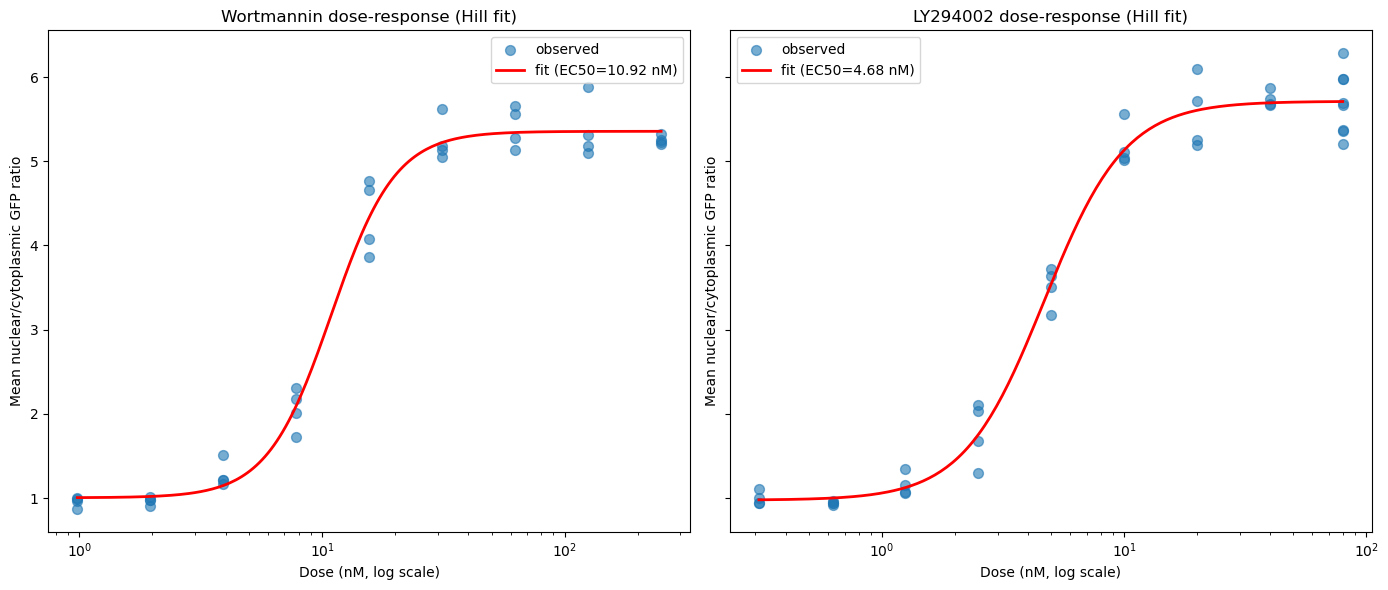

In [6]:
def four_param_logistic(x, bottom, top, ec50, hill_slope):
    return bottom + (top - bottom) / (1 + (ec50 / x) ** hill_slope)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fit_results = {}

for ax, drug in zip(axes, ["Wortmannin", "LY294002"]):
    drug_data = well_summary[(well_summary["drug"] == drug) & (well_summary["dose_nM"] > 0) & (well_summary["category"] != "positive_control")]
    x_data = drug_data["dose_nM"].values
    y_data = drug_data["mean_nuc_cyto_ratio"].values
    p0 = [1, 6, 10, 1]
    popt, pcov = curve_fit(four_param_logistic, x_data, y_data, p0=p0, maxfev=10000)
    bottom, top, ec50, hill_slope = popt
    fit_results[drug] = {"bottom": bottom, "top": top, "ec50": ec50, "hill_slope": hill_slope}

    x_smooth = np.logspace(np.log10(x_data.min()), np.log10(x_data.max()), 200)
    y_smooth = four_param_logistic(x_smooth, *popt)
    ax.scatter(x_data, y_data, alpha=0.6, s=50, label="observed")
    ax.plot(x_smooth, y_smooth, color="red", linewidth=2, label=f"fit (EC50={ec50:.2f} nM)")
    ax.set_xscale("log")
    ax.set_xlabel("Dose (nM, log scale)")
    ax.set_ylabel("Mean nuclear/cytoplasmic GFP ratio")
    ax.set_title(f"{drug} dose-response (Hill fit)")
    ax.legend()
    print(f"{drug}: EC50 = {ec50:.2f} nM, Hill slope = {hill_slope:.2f}, bottom = {bottom:.2f}, top = {top:.2f}")

plt.tight_layout()
plt.savefig("results/figures/dose_response_fitted.png", dpi=150)
plt.show()

Both curves show a clear sigmoidal shape. The fitted EC50 values show LY294002
(4.68nM) is more potent than Wortmannin (10.92nM) at inducing translocation in this
assay. This is worth noting because, before fitting, the raw scatter plot of
LY294002 appeared visually shifted to higher doses compared with Wortmannin,
suggesting the opposite conclusion. The fitted curve gives the more reliable answer,
and shows the value of fitting a proper model rather than reading a trend from a
scatter plot by eye.

## 7. Assay quality metrics: Z'-factor and V-factor

The BBBC013 dataset page reports Z' factor and V-factor values from previous studies
using this same image set (Carpenter et al., 2006; Logan and Carpenter, 2010),
giving a direct point of comparison for the pipeline built here.

The Z'factor (Zhang, Chung and Oldenburg, 1999) uses only the positive and negative
control wells:

Z' = 1 - 3(sigma_p + sigma_n) / |mu_p - mu_n|

The V-factor (Bray and Carpenter, 2017) is a generalisation of the Z'factor to the
whole dose response curve, using the standard deviation across replicates at each
dose and the top/bottom of the fitted response range:

V = 1 - 3 * mean(sigma_dose) / |top - bottom|

In [7]:
def calc_z_prime(pos_values, neg_values):
    mu_p, sigma_p = np.mean(pos_values), np.std(pos_values, ddof=1)
    mu_n, sigma_n = np.mean(neg_values), np.std(neg_values, ddof=1)
    z_prime = 1 - (3 * (sigma_p + sigma_n)) / abs(mu_p - mu_n)
    return z_prime, mu_p, sigma_p, mu_n, sigma_n

# Z'-factor: Wortmannin uses its true positive control; LY294002 uses its highest dose as a substitute
wort_neg = well_summary[(well_summary["drug"] == "Wortmannin") & (well_summary["category"] == "negative_control")]
wort_pos = well_summary[(well_summary["drug"] == "Wortmannin") & (well_summary["category"] == "positive_control")]
z_wort, *_ = calc_z_prime(wort_pos["mean_nuc_cyto_ratio"], wort_neg["mean_nuc_cyto_ratio"])

ly_neg = well_summary[(well_summary["drug"] == "LY294002") & (well_summary["dose_nM"] == 0)]
ly_pos_substitute = well_summary[(well_summary["drug"] == "LY294002") & (well_summary["dose_nM"] == 80)]
z_ly, *_ = calc_z_prime(ly_pos_substitute["mean_nuc_cyto_ratio"], ly_neg["mean_nuc_cyto_ratio"])

print(f"Wortmannin: Z' = {z_wort:.3f}")
print(f"LY294002: Z' = {z_ly:.3f} (using highest tested dose, 80nM, as substitute positive control)")

print("\n--- V-factor ---")
for drug in ["Wortmannin", "LY294002"]:
    drug_wells = well_summary[(well_summary["drug"] == drug) & (well_summary["dose_nM"] > 0)]
    dose_stats = drug_wells.groupby("dose_nM")["mean_nuc_cyto_ratio"].agg(["mean", "std"]).reset_index()
    avg_sigma = dose_stats["std"].mean()
    top, bottom = dose_stats["mean"].max(), dose_stats["mean"].min()
    v_factor = 1 - (3 * avg_sigma) / abs(top - bottom)
    print(f"{drug}: V-factor = {v_factor:.3f}")

Wortmannin: Z' = 0.850
LY294002: Z' = 0.728 (using highest tested dose, 80nM, as substitute positive control)

--- V-factor ---
Wortmannin: V-factor = 0.866
LY294002: V-factor = 0.863


Both Z'factor values (0.850 Wortmannin, 0.728 LY294002) fall in the range considered
excellent for a screening assay (Z' > 0.5), and are broadly comparable to the
published values on the BBBC013 page (0.94 and 0.90 respectively), with the
difference likely explained by the use of a substitute positive control for
LY294002 and a simpler, non tuned segmentation method here rather than the original
study's pipeline. The V factor values (0.866 Wortmannin, 0.863 LY294002) are very
close to the published reference values (0.86 and 0.84-0.88), giving good
independent confirmation that the pipeline built here performs comparably to
published, more specialised methods.

## 8. Discussion and limitations

This project built a complete image analysis pipeline, from raw microscopy images to
dose response curves and assay quality metrics, using classical segmentation methods
rather than a pre trained model. The segmentation was validated visually and
quantitatively before being run across the full plate, and the resulting
dose response curves and quality metrics compare well with previously published
results using this same dataset.

A labelling assumption error was caught during the analysis: the plate layout for
LY294002 does not follow the same column pattern as Wortmannin, and this was only
identified by checking the raw per well values rather than trusting the initial
assumption. This is noted here because it reflects a broader point about verifying
metadata assumptions directly against the data, rather than generalising from a
single check.

Limitations:

- Classical thresholding and watershed segmentation can struggle with very dense or
  overlapping cell populations; a small number of nuclei may have been merged or
  over segmented, which was not directly quantified against a ground truth here.
- The cytoplasm ring definition (dilating the nucleus by a fixed number of pixels)
  is a simplification; it does not account for actual cell boundaries and may
  include some background or neighbouring cell signal, particularly in
  densely packed wells.
- LY294002 has no genuine off curve positive control in this dataset, so its
  Z' factor used the highest tested dose as a substitute, which likely
  underestimates the true value compared with using a saturating positive control.

## 9. References

- Ljosa, V., Sokolnicki, K. & Carpenter, A. (2012) ‘Annotated high-throughput microscopy image sets for validation’. Nature Methods 9, 637
  Doi.10.1038/nmeth.2083
- Zhang, J. H., Chung, T. D., & Oldenburg, K. R. (1999). ‘A Simple Statistical Parameter for Use in Evaluation and Validation of High Throughput
  Screening Assays’. Journal of biomolecular screening, 4(2), 67–73. Doi:10.1177/108705719900400206
- Bray, MA &Carpenter. A. (2017) ‘Imaging Platform, Broad Institute of MIT and Harvard. Advanced Assay Development Guidelines for Image-Based High
  Content Screening and Analysis’. [online] Available at: https://www.ncbi.nlm.nih.gov/books/NBK126174/
- Carpenter, A. E., Jones, T. R., Lamprecht, M. R., Clarke, C., Kang, I. H., Friman, O., Guertin, D. A., Chang, J. H., Lindquist, R. A., Moffat, J.,
  Golland, P., & Sabatini, D. M. (2006). ‘CellProfiler: image analysis software for identifying and quantifying cell phenotypes’. Genome biology,
  7(10), R100. Doi:10.1186/gb-2006-7-10-r100
- Logan, D. J., & Carpenter, A. E. (2010). ‘Screening cellular feature measurements for image-based assay development’. Journal of biomolecular
  screening, 15(7), pp.840–846. Doi:10.1177/1087057110370895
  